In [1]:
import torch
from torch import nn
from torch.utils.data import DataLoader
from torch.nn import functional as F

from skimage.metrics import structural_similarity as ssim
import matplotlib.pyplot as plt

In [2]:
device = torch.device("cuda") if torch.cuda.is_available() else torch.device("cpu")
print("Device:", device)

Device: cuda


In [3]:
from dival import get_standard_dataset

dataset = get_standard_dataset(
    "custom",
    data_path="../data/dataset_S2010",
    sinogram_shape=(512, 365),
    image_shape=(256, 256),
    parts_len={"train": 128, "validation": 16, "test": 17},
    impl="skimage",
)

test_dataset = dataset.create_torch_dataset(part="train")

In [10]:
batch_size = 8

test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=4,
    pin_memory=True,
)

In [ ]:
from models.Pix2Pix_256_V1 import UnetGenerator

In [6]:
generator = UnetGenerator().to(device)

checkpoint = torch.load("../models/256x256_0212_pix2pix.pth", map_location=device)

generator.load_state_dict(checkpoint)

<All keys matched successfully>

In [14]:
def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

print("Number of trainable parameters:", count_parameters(generator))

Number of trainable parameters: 7336545


In [12]:
import math
import numpy as np

def calculate_psnr(img1, img2, max_val=1.0):
    mse = np.mean((img1 - img2) ** 2)
    if mse == 0:
        return float('inf')
    return 20 * math.log10(max_val) - 10 * math.log10(mse)

In [13]:
mse_criterion = nn.MSELoss()

generator.eval()
mse_test_loss = 0.0
ssim_val_loss = 0.0
psnr_val = 0.0

with torch.no_grad():
    for sino, img in test_loader:
        sino = sino.unsqueeze(1).to(device, non_blocking=True)
        img = img.unsqueeze(1).to(device, non_blocking=True)

        output = generator(sino)
        loss = mse_criterion(output, img)
        mse_test_loss += loss.item()

        output_np = output.squeeze().cpu().numpy()
        img_np = img.squeeze().cpu().numpy()
        ssim_value = ssim(
            img_np, output_np, data_range=img_np.max() - img_np.min()
        )
        # Ensure we accumulate only the scalar score.
        if isinstance(ssim_value, (tuple, list)):
            ssim_value = ssim_value[0]
        ssim_val_loss += float(ssim_value)

        psnr_val += calculate_psnr(img_np, output_np, max_val=1.0)

    mse_test_loss /= len(test_loader)
    ssim_val_loss /= len(test_loader)
    psnr_val /= len(test_loader)

print(
    f"Val Loss: {mse_test_loss:.6f} | "
    f"Val SSIM: {ssim_val_loss:.4f} | "
    f"Val PSNR: {psnr_val:.4f}"
)

Val Loss: 0.000945 | Val SSIM: 0.8921 | Val PSNR: 30.3393


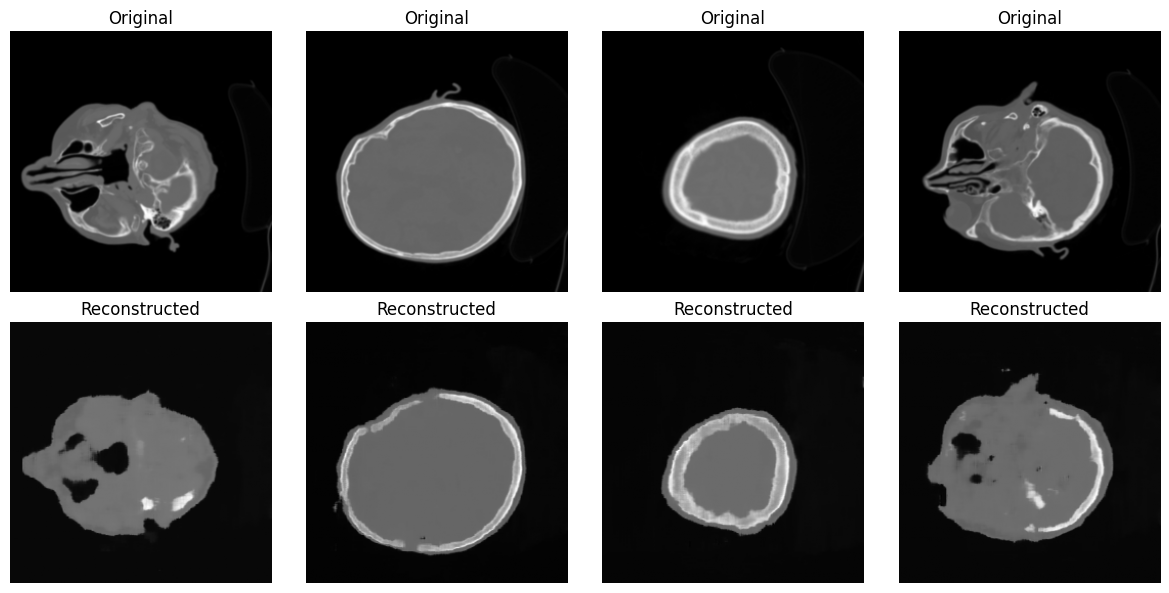

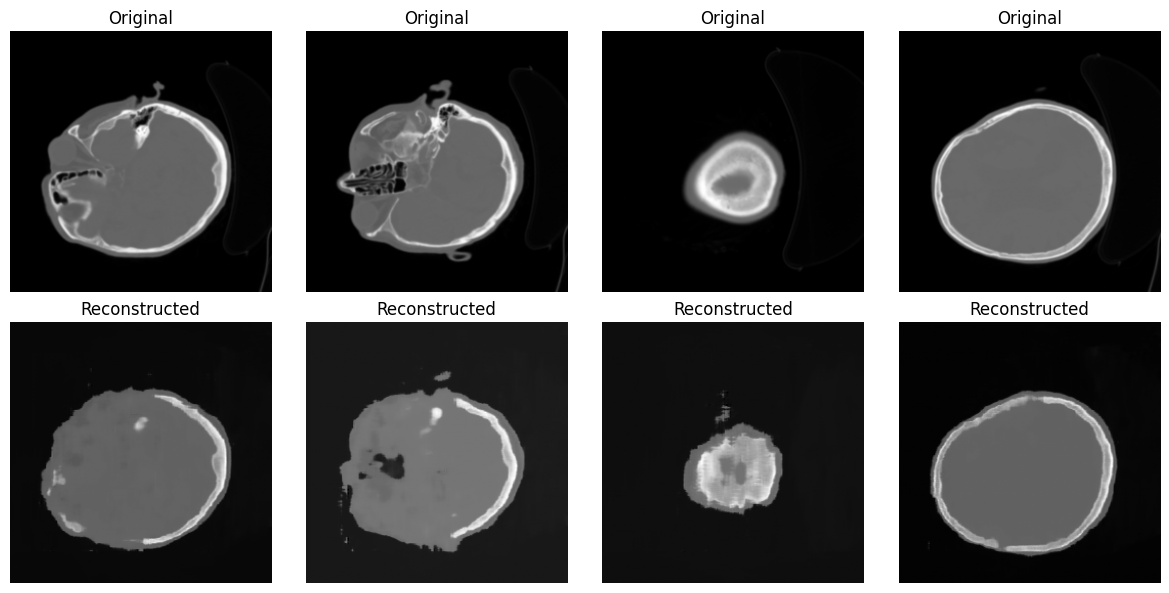

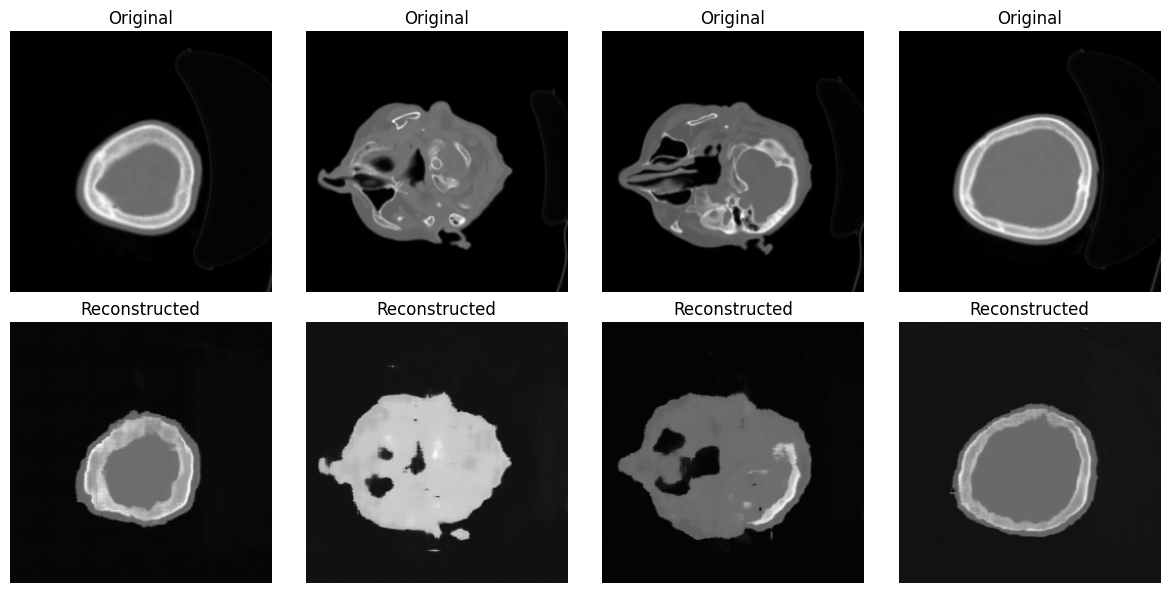

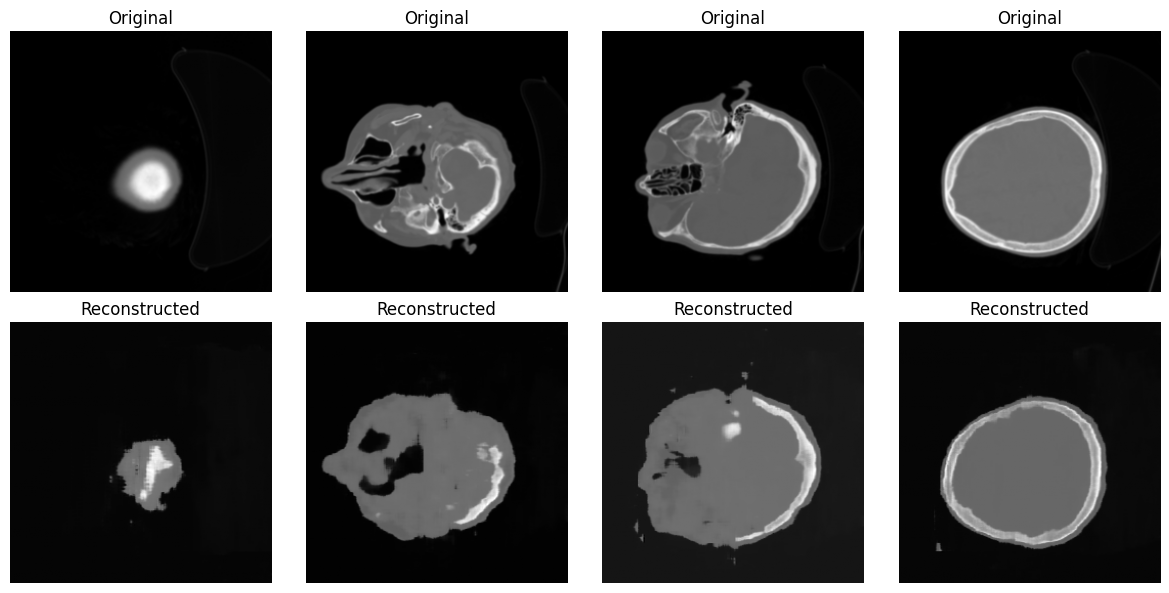

Average inference time per image: 0.0229 seconds


In [7]:
import matplotlib.pyplot as plt
import time


def show_reconstructed_images(model, dataloader, device, num_images=5):
    model.eval()
    shown = 0
    inference_times = []
    with torch.no_grad():
        for sino, img in dataloader:
            sino = sino.unsqueeze(1).to(device, non_blocking=True)
            img = img.unsqueeze(1).to(device, non_blocking=True)

            start_time = time.time()
            output = model(sino)
            end_time = time.time()
            inference_times.append(end_time - start_time)

            batch_size = img.size(0)
            n = min(batch_size, num_images - shown)

            # Create a figure with 2 rows: original and reconstructed
            fig, axes = plt.subplots(nrows=2, ncols=n, figsize=(3 * n, 6))

            for i in range(n):
                # Original image
                axes[0, i].imshow(img[i].cpu().numpy().squeeze(), cmap="gray")
                axes[0, i].set_title("Original")
                axes[0, i].axis("off")

                # Reconstructed image
                axes[1, i].imshow(output[i].cpu().numpy().squeeze(), cmap="gray")
                axes[1, i].set_title("Reconstructed")
                axes[1, i].axis("off")

            plt.tight_layout()
            plt.show()

            shown += n
            if shown >= num_images:
                break

    average_inference_time = sum(inference_times) / len(inference_times)
    print(
        f"Average inference time per image: {(average_inference_time / batch_size):.4f} seconds"
    )


show_reconstructed_images(generator, test_loader, device, num_images=16)